In [ ]:
import time
import torch
import os
import sys
from torch.distributions import Categorical, kl
import IPython.display as display

if not hasattr(display, "set_matplotlib_formats"):
    # no-op fallback (or you can force retina/png instead)
    def set_matplotlib_formats(*args, **kwargs):
        return None
    display.set_matplotlib_formats = set_matplotlib_formats

from pathlib import Path

from d2l.torch import Animator

from net import Net
from faco import MFACO_CVRP
from utils import gen_instance_for_mfaco, load_val_dataset

from tqdm import tqdm
import pathlib

PROJECT_ROOT = Path.cwd().resolve()

PRETRAINED_DIR = PROJECT_ROOT / "../pretrained"

# Optional wandb logging (lazy import to avoid hangs at import-time)
USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "ngfaco")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY") or None
WANDB_MODE = os.environ.get("WANDB_MODE", "online")  # set to "offline" to avoid network
wandb = None

def _wandb_init(config: dict, name: str | None = None):
    """Init a fresh wandb run for each train() call.

    In notebooks it's common to re-run the train cell; reusing the same wandb run
    causes non-monotonic step warnings when we log with an explicit `step=`.
    """
    global wandb, USE_WANDB
    if not USE_WANDB:
        return None
    if wandb is None:
        try:
            import wandb as _wandb
            wandb = _wandb
        except Exception as e:
            USE_WANDB = False
            print("wandb disabled (import failed):", e)
            return None
    if wandb.run is not None:
        # Start a new run to avoid step going backwards on re-runs.
        try:
            wandb.finish()
        except Exception:
            pass
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        config=config,
        name=name,
        mode=WANDB_MODE,
    )

torch.manual_seed(1234)

lr = 3e-4
EPS = 1e-10
H = 20
disable_heuristic = False
use_local_search = True
rho = 0.1

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

/home/shora/Research/old/NGFACO/data


In [2]:
import numpy as np
import torch
from torch_geometric.data import Data

def _popcount_i64(x: torch.Tensor) -> torch.Tensor:
    """
    Vectorized popcount for int64 tensor x (CUDA-safe).
    Interprets bits in two's complement; for non-negative values this matches uint64 popcount.
    Returns int64 counts in [0, 64].
    """
    if x.dtype != torch.int64:
        raise TypeError(f"_popcount_i64 expects torch.int64, got {x.dtype}")

    # Masks as int64 constants (fit within signed range)
    m1  = x.new_tensor(0x5555555555555555, dtype=torch.int64)
    m2  = x.new_tensor(0x3333333333333333, dtype=torch.int64)
    m4  = x.new_tensor(0x0F0F0F0F0F0F0F0F, dtype=torch.int64)
    h01 = x.new_tensor(0x0101010101010101, dtype=torch.int64)

    # Assumes x is non-negative (your valid_mask should be)
    x = x - ((x >> 1) & m1)
    x = (x & m2) + ((x >> 2) & m2)
    x = (x + (x >> 4)) & m4
    return (x * h01) >> 56


def replay_logp_from_cpp_batch_trace(traces, prob_sparse: torch.Tensor):
    """
    Reconstruct per-ant logp from C++ trace + differentiable (n,k) prob weights.

    traces: faco_cvrp.MFACOTrace
    prob_sparse: torch.Tensor (n,k) unnormalized weights, differentiable w.r.t residual logits
    """
    device = prob_sparse.device
    k = int(prob_sparse.size(1))
    if k > 64:
        raise ValueError(f"k={k} > 64 but trace.valid_mask is 64-bit; store n_valid explicitly or widen mask.")

    # Trace arrays -> torch (non-diff)
    curr = torch.as_tensor(np.asarray(traces.curr_nodes, dtype=np.int64), device=device)
    is_stoch = torch.as_tensor(np.asarray(traces.is_stochastic, dtype=np.uint8), device=device).bool()
    used_unif = torch.as_tensor(np.asarray(traces.used_uniform, dtype=np.uint8), device=device).bool()
    pick = torch.as_tensor(np.asarray(traces.pick_j, dtype=np.int64), device=device)

    # IMPORTANT: keep mask as int64 on GPU to allow bit ops + indexing
    vm_i64 = torch.as_tensor(np.asarray(traces.valid_mask, dtype=np.uint64), device=device).to(torch.int64)

    # Ant mapping on GPU
    starts_t = torch.as_tensor(np.asarray(traces.starts, dtype=np.int64), device=device, dtype=torch.int64)
    n_ants = int(getattr(traces, "n_ants", int(starts_t.numel() - 1)))
    counts_t = (starts_t[1:1+n_ants] - starts_t[:n_ants]).to(torch.int64)

    ant_idx_all = torch.repeat_interleave(
        torch.arange(n_ants, device=device, dtype=torch.int64),
        counts_t,
    )

    # ndec per ant (stochastic only)
    if bool(is_stoch.any().item()):
        ndec = torch.bincount(ant_idx_all[is_stoch], minlength=n_ants).to(torch.int32)
    else:
        ndec = torch.zeros((n_ants,), device=device, dtype=torch.int32)

    logp = torch.zeros((n_ants,), device=device, dtype=torch.float32)

    # --- Roulette steps ---
    roulette = is_stoch & (~used_unif) & (pick >= 0)
    if bool(roulette.any().item()):
        idx = roulette.nonzero(as_tuple=False).squeeze(1)
        curr_r = curr[idx]
        pick_r = pick[idx]

        in_range = (pick_r >= 0) & (pick_r < k)
        if not bool(in_range.all().item()):
            bad = pick_r[~in_range][:10].detach().cpu().tolist()
            raise ValueError(f"pick_j out of range (k={k}). Examples: {bad}")

        vm_r = vm_i64[idx]  # int64, CUDA-indexable
        w = prob_sparse[curr_r]  # (D_r, k), differentiable

        # Build validity matrix from bitmask (all int64 ops, then cast)
        bitpos = torch.arange(k, device=device, dtype=torch.int64)
        valid = ((vm_r.unsqueeze(1) >> bitpos) & 1).to(w.dtype)

        denom = (w * valid).sum(dim=1).clamp_min(1e-12)
        numer = w.gather(1, pick_r.unsqueeze(1)).squeeze(1).clamp_min(1e-12)

        chosen_valid = (((vm_r >> pick_r) & 1) != 0)
        if not bool(chosen_valid.all().item()):
            raise ValueError("Trace inconsistency: pick_j not valid under valid_mask for some roulette decisions.")

        lp = torch.log(numer / denom)
        logp.scatter_add_(0, ant_idx_all[idx], lp)

    # --- Uniform steps ---
    unif = is_stoch & used_unif
    if bool(unif.any().item()):
        idx = unif.nonzero(as_tuple=False).squeeze(1)
        vm_u = vm_i64[idx]  # int64
        m = _popcount_i64(vm_u).to(torch.float32)
        lp = -torch.log(m.clamp_min(1.0))
        logp.scatter_add_(0, ant_idx_all[idx], lp)

    return logp, ndec


def prob_sparse_torch_cvrp(aco: MFACO_CVRP, residual_logits: torch.Tensor, invtemp: float = 1.0) -> torch.Tensor:
    """
    CVRP analog of MFACO_TSP.prob_sparse_torch().
    Returns unnormalized candidate weights (n,k) on the same device as residual_logits.
    """
    dev = residual_logits.device
    tau = torch.as_tensor(np.asarray(aco.pheromone_sparse_np), device=dev, dtype=torch.float32).clamp_min(1e-10)
    tau = tau ** 1.0  # alpha is 1.0 in this notebook

    if disable_heuristic:
        w = tau
    else:
        h = torch.as_tensor(np.asarray(aco.heuristic_sparse_np), device=dev, dtype=torch.float32).clamp_min(1e-12)
        if invtemp != 1.0:
            h = h ** float(invtemp)
        w = tau * h
    w = w.clamp_min(1e-12)

    if residual_logits is not None:
        residual_clamped = residual_logits.clamp(-10.0, 10.0)
        w = w * torch.exp(residual_clamped)

    return w


def build_pyg_data_cvrp(aco: MFACO_CVRP, coords, demand, device: str, dynamic: bool) -> Data:
    """
    Build a PyG graph matching MFACO_CVRP's sparse candidate graph (n,k).

    Node features:
      x: coords (n,2)
    Edge features (E=n*k, 6):
      0 dist_norm
      1 tau_cv
      2 log_tau_rel (dynamic) else 0
      3 is_source_succ (customer tour)
      4 is_source_pred (customer tour)
      5 is_new_edge (not adjacent in source tour among customers)
    """
    if isinstance(coords, np.ndarray):
        coords_t = torch.from_numpy(coords)
    elif isinstance(coords, torch.Tensor):
        coords_t = coords
    else:
        coords_t = torch.as_tensor(coords)
    coords_t = coords_t.to(device=device, dtype=torch.float32)  # (n,2)
    demand_t = torch.as_tensor(demand, device=device, dtype=torch.float32)  # (n,)

    nn = torch.as_tensor(np.asarray(aco.nn_list, dtype=np.int64), device=device, dtype=torch.long)  # (n,k)
    n, k = nn.shape
    E = n * k

    src = torch.arange(n, device=device, dtype=torch.long).repeat_interleave(k)
    dst = nn.reshape(-1)
    edge_index = torch.stack([src, dst], dim=0)

    # 0) dist_norm
    dist = torch.norm(coords_t[src] - coords_t[dst], dim=1).view(n, k)
    dist_mean = dist.mean(dim=1, keepdim=True).clamp_min(1e-12)
    dist_norm = (dist / dist_mean).view(E, 1)

    # 1-2) tau features
    if dynamic:
        tau = torch.as_tensor(np.asarray(aco.pheromone_sparse_np), device=device, dtype=torch.float32).clamp_min(1e-12)
        tau_mean = tau.mean(dim=1, keepdim=True).clamp_min(1e-12)
        tau_rel = (tau / tau_mean).clamp_min(1e-12)
        log_tau_rel = torch.log(tau_rel).clamp(-5.0, 5.0).view(E, 1)
        tau_std = tau.std(dim=1, keepdim=True)
        tau_cv = (tau_std / tau_mean).clamp(0, 10)
        tau_cv_e = tau_cv.repeat_interleave(k, dim=0)
    else:
        log_tau_rel = torch.zeros((E, 1), device=device, dtype=torch.float32)
        tau_cv_e = torch.zeros((E, 1), device=device, dtype=torch.float32)

    # Source-perm features (customers only; depot gets -1)
    src_perm = torch.as_tensor(np.asarray(aco.solver.source_perm, dtype=np.int64), device=device, dtype=torch.long)  # (m,)
    succ = torch.full((n,), -1, device=device, dtype=torch.long)
    pred = torch.full((n,), -1, device=device, dtype=torch.long)
    if src_perm.numel() > 0:
        succ[src_perm] = torch.roll(src_perm, shifts=-1)
        pred[src_perm] = torch.roll(src_perm, shifts=+1)

    is_source_succ = (dst == succ[src]).to(torch.float32).view(E, 1)
    is_source_pred = (dst == pred[src]).to(torch.float32).view(E, 1)

    pos = torch.full((n,), -1, device=device, dtype=torch.long)
    if src_perm.numel() > 0:
        pos[src_perm] = torch.arange(src_perm.numel(), device=device, dtype=torch.long)
        m = int(src_perm.numel())
        duv = (pos[src] - pos[dst]).abs()
        undirected_adj = ((duv == 1) | (duv == (m - 1))) & (pos[src] >= 0) & (pos[dst] >= 0)
    else:
        undirected_adj = torch.zeros((E,), device=device, dtype=torch.bool)

    is_new_edge = (~undirected_adj).to(torch.float32).view(E, 1)

    edge_attr = torch.cat(
        [dist_norm, tau_cv_e, log_tau_rel, is_source_succ, is_source_pred, is_new_edge],
        dim=1,
    )

    depot_flag = torch.zeros((coords_t.size(0), 1), device=device)
    depot_flag[0, 0] = 1.0
    coords_t = torch.cat([coords_t, demand_t.unsqueeze(-1), depot_flag], dim=-1)

    return Data(x=coords_t, edge_index=edge_index, edge_attr=edge_attr)


In [3]:
def train_instance(model, optimizer, coords, demand, capacity, k_sparse, n_ants, dynamic):
    model.train()

    aco = MFACO_CVRP(
        coords=coords,
        demand=demand,
        capacity=capacity,
        n_ants=n_ants,
        cand_list_size=k_sparse,
        backup_list_size=k_sparse,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        decay=rho,
    )

    # Accumulate training signal across H iterations
    losses = []
    avg_cost = None
    best_cost = None

    for t in range(H):
        pyg_data = build_pyg_data_cvrp(aco, coords, demand, device, dynamic=dynamic)
        heu_vec = model(pyg_data).view(-1)
        heu_mat = heu_vec.view(aco.n, aco.k) + EPS

        # 1) sample + trace from C++
        costs_np, perms, _, traces = aco.sample(require_prob=True, residual_logits=heu_mat)
        costs_t = torch.as_tensor(np.asarray(costs_np, dtype=np.float32), device=device)

        # 2) differentiable prob weights table (DO NOT use C++ probmat for training)
        prob_sparse = prob_sparse_torch_cvrp(aco, residual_logits=heu_mat)
        logp_per_ant, _ = replay_logp_from_cpp_batch_trace(traces, prob_sparse)  # (n_ants,)

        # 3) REINFORCE loss for THIS iteration (baseline = mean in batch)
        baseline = costs_t.mean()
        adv = (costs_t - baseline).detach()

        w = (t + 1) / H   # t=0..H-1
        # losses.append(w * (adv * logp_per_ant).mean())
        loss = w * (adv * logp_per_ant).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        # 4) ACO pheromone update (best ant of this iteration)
        best_idx = int(costs_t.argmin().item())
        best_cost = float(costs_t[best_idx].item())
        best_perm = perms[best_idx]
        aco.update_pheromone(best_perm, best_cost)

        avg_cost = float(costs_t.mean().item())

    # loss = torch.stack(losses).sum() / (torch.tensor([(i+1)/H for i in range(H)], device=device).sum())
    # optimizer.zero_grad(set_to_none=True)
    # loss.backward()
    # optimizer.step()

    return avg_cost, best_cost


@torch.no_grad()
def infer_instance(model, coords, demand, capacity, k_sparse, n_ants, dynamic):
    model.eval()

    aco = MFACO_CVRP(
        coords=coords,
        demand=demand,
        capacity=capacity,
        n_ants=n_ants,
        cand_list_size=k_sparse,
        backup_list_size=k_sparse,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        decay=rho,
    )

    best_seen = float("inf")
    avg_last = None

    for _ in range(H):
        pyg_data = build_pyg_data_cvrp(aco, coords, demand, device, dynamic=dynamic)
        heu_vec = model(pyg_data).view(-1)
        heu_mat = heu_vec.view(aco.n, aco.k) + EPS

        costs_np, perms, _, _ = aco.sample(require_prob=False, residual_logits=heu_mat)
        costs_t = torch.as_tensor(np.asarray(costs_np, dtype=np.float32), device=device)

        avg_last = float(costs_t.mean().item())
        best_idx = int(costs_t.argmin().item())
        best_cost = float(costs_t[best_idx].item())
        best_seen = min(best_seen, best_cost)

        aco.update_pheromone(perms[best_idx], best_cost)

    return avg_last, best_seen

In [4]:
def train_epoch(n_customers,
                n_ants,
                k_sparse,
                epoch,
                steps_per_epoch,
                net,
                optimizer,
                dynamic,
                global_step
                ):

    for step in range(steps_per_epoch):
        coords_t, demand_t, capacity = gen_instance_for_mfaco(n_customers, device='cpu')
        coords = coords_t.detach().cpu().numpy().astype(np.float32)
        demand = demand_t.detach().cpu().numpy().astype(np.float32)

        avg_cost, best_cost = train_instance(net, optimizer, coords, demand, float(capacity), k_sparse, n_ants, dynamic)

        if USE_WANDB and wandb is not None:
            wandb.log({
                "train/avg_cost": float(avg_cost),
                "train/best_cost": float(best_cost),
                "train/epoch": int(epoch),
                "train/step_in_epoch": int(step) + 1,
            }, step=global_step)

        global_step += 1
    return global_step


@torch.no_grad()
def validation(n_ants, epoch, net, val_set, k_sparse, animator, dynamic):
    sum_sample_best, sum_aco_best = 0.0, 0.0

    for coords, demand, capacity in val_set:
        avg_last, best_seen = infer_instance(net, coords, demand, capacity, k_sparse, n_ants, dynamic)
        sum_sample_best += avg_last
        sum_aco_best += best_seen


    n_val = len(val_set)
    avg_last = sum_sample_best / n_val
    avg_aco_best = sum_aco_best / n_val
    if animator:
        animator.add(epoch+1, (avg_last, avg_aco_best))

    return avg_last, avg_aco_best

In [ ]:
def train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs, dynamic = True):
    run = _wandb_init({
        "problem": "cvrp",
        "n_customers": int(n_customers),
        "k_sparse": int(k_sparse),
        "n_ants": int(n_ants),
        "steps_per_epoch": int(steps_per_epoch),
        "epochs": int(epochs),
        "H": int(H),
        "lr": float(lr),
        "rho": float(rho),
        "disable_heuristic": bool(disable_heuristic),
        "use_local_search": bool(use_local_search),
        "device": str(device),
    }, name=f"cvrp{int(n_customers)}")

    net = Net().to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)

    val_set = load_val_dataset(n_customers, device=device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs],
                        legend=["Avg. sample obj.", "Best ACO obj."])

    avg_last, avg_aco_best = validation(n_ants, -1, net, val_set, k_sparse, animator, dynamic)
    val_results = [(avg_last, avg_aco_best)]

    global_step = 0
    if USE_WANDB and wandb is not None:
        wandb.log({
            "val/avg_last": float(avg_last),
            "val/avg_best": float(avg_aco_best),
            "val/epoch": -1,
        }, step=global_step)
        global_step += 1

    sum_time = 0.0
    best_val = float('inf')
    for epoch in range(0, epochs):
        start = time.time()
        global_step = train_epoch(n_customers, n_ants, k_sparse, epoch, steps_per_epoch, net, optimizer, dynamic, global_step=global_step)
        sum_time += time.time() - start
        avg_last, avg_aco_best = validation(n_ants, epoch, net, val_set, k_sparse, animator, dynamic)
        val_results.append((avg_last, avg_aco_best))
        if USE_WANDB and wandb is not None:
            wandb.log({
                "val/avg_last": float(avg_last),
                "val/avg_best": float(avg_aco_best),
                "val/epoch": int(epoch),
            }, step=global_step)
        
        if avg_aco_best < best_val:
            best_val = avg_aco_best
            pathlib.Path(f'{PRETRAINED_DIR}/cvrp').mkdir(parents=True, exist_ok=True)
            torch.save(net.state_dict(), f'{PRETRAINED_DIR}/cvrp/cvrp{n_customers}.pt')

    print('total training duration:', sum_time)

    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch+1])

    if USE_WANDB and wandb is not None and wandb.run is not None:
        wandb.finish()

total training duration: 193.00072717666626
epoch -1: (14.753330431878567, 13.82334042340517)
epoch 0: (14.534246169030666, 13.723517268896103)
epoch 1: (14.517031483352184, 13.69904413819313)
epoch 2: (14.534135363996029, 13.73659112304449)
epoch 3: (14.546045295894146, 13.739809826016426)
epoch 4: (14.537706419825554, 13.719647362828255)
epoch 5: (14.519293136894703, 13.71262140572071)
epoch 6: (14.513066604733467, 13.708197966217995)
epoch 7: (14.517701983451843, 13.727104291319847)
epoch 8: (14.53263407945633, 13.73415543884039)
epoch 9: (14.533798649907112, 13.715152345597744)


train/avg_cost,▄▄▆▅▅▆▄▄▅▄▃▃▆▂▅▄▄▆▁▇▅▅▄▂▅█▄▃▄▄▇▃▆█▅▄▅▄▅▄
train/best_cost,▇▆▅▅▅▄▄▅▄█▆▅▅▃▅▄▂▃▆▄▄▄▅▄▆▅▅▆▂▃▆▃▃▄▁▃▅▂▃▃
train/epoch,▁▁▁▁▂▃▃▃▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇██
train/step_in_epoch,▄▄▆▇█▁▁▂▃▆▂▅▇█▂▆▇▁▂▃▂▃▃▄▆▇▇▇█▂▃▃▄▂▄▅█▁▃▅
val/avg_best,█▂▁▃▃▂▂▂▃▃▂
val/avg_last,█▂▁▂▂▂▁▁▁▂▂
val/epoch,▁▂▂▃▄▅▅▆▇▇█
train/avg_cost,14.1943
train/best_cost,13.33112
train/epoch,9
train/step_in_epoch,64


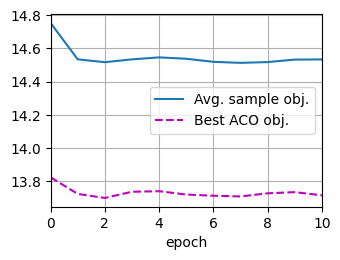

In [6]:
n_customers, n_ants = 100, 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10

train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs)

total training duration: 192.2239944934845
epoch -1: (25.346034333109856, 24.515768736600876)
epoch 0: (25.144694223999977, 24.392624959349632)
epoch 1: (25.092306420207024, 24.366314128041267)
epoch 2: (25.12721425294876, 24.38306511938572)
epoch 3: (25.10211271047592, 24.37962993979454)
epoch 4: (25.11776864528656, 24.373681664466858)
epoch 5: (25.12402345240116, 24.39822167158127)
epoch 6: (25.122813925147057, 24.375784769654274)
epoch 7: (25.126135930418968, 24.385338321328163)
epoch 8: (25.099006310105324, 24.367300793528557)
epoch 9: (25.12704737484455, 24.380384728312492)


train/avg_cost,▆▃▅█▄▆▅▂▄▄▆▆▃▃▆▄▅▂▂█▃▂▄▅▂▆▄▂▂█▁▅▃▆▆▄▂▅▁▅
train/best_cost,▂▇▄▃▄▂▅▃▄▅▄▄▆▅█▇▃▇▆▃▁▅▅▃▄▄▂▆▅▄▅▅█▅▃▁▄▅█▅
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇█
train/step_in_epoch,▄▄▅▅▇▃▆█▂▂▅▅▆▁▁▃▂▂▃▅▁▂▄▅█▄▅▅▇█▅▅▇▄▄▇█▂▇█
val/avg_best,█▂▁▂▂▁▂▁▂▁▂
val/avg_last,█▂▁▂▁▂▂▂▂▁▂
val/epoch,▁▂▂▃▄▅▅▆▇▇█
train/avg_cost,24.80445
train/best_cost,24.1049
train/epoch,9
train/step_in_epoch,64


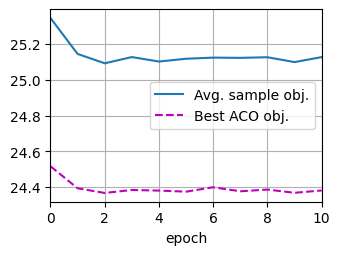

In [7]:
n_customers, n_ants = 200, 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10

train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs)

total training duration: 432.6893765926361
epoch -1: (55.26004076004028, 54.49351590871811)
epoch 0: (55.04116466641426, 54.32225948572159)
epoch 1: (55.013117879629135, 54.31010776758194)
epoch 2: (55.01782861351967, 54.314246475696564)
epoch 3: (54.96727415919304, 54.27620467543602)
epoch 4: (54.96255898475647, 54.2681730389595)
epoch 5: (54.96102726459503, 54.28002631664276)
epoch 6: (54.99179792404175, 54.310572296381)
epoch 7: (54.92484670877457, 54.244946002960205)
epoch 8: (54.98901030421257, 54.30287018418312)
epoch 9: (54.98506337404251, 54.293317049741745)


train/avg_cost,▇▆▂▂▆█▁▆▄▄▄▄▄▅▁▄▅▃█▃▆▃▄▅▄▅▅▅█▃▅▆▅█▂▅█▅▃▆
train/best_cost,▆█▅▃▁▄▄▅▄▅▃▇▅▆▆▆▆▅▁▄▅▅▅▅▆▃▅▅▄▄▆▇▄▆▅▅▄▅▇▇
train/epoch,▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆██
train/step_in_epoch,▄▄▅▆▁▃▄▅▆▇▂▆▇██▂▆▇█▂▆▇▄▄▅▇▂▃▃▆▇█▁▄▄▁▃▄▅▇
val/avg_best,█▃▃▃▂▂▂▃▁▃▂
val/avg_last,█▃▃▃▂▂▂▂▁▂▂
val/epoch,▁▂▂▃▄▅▅▆▇▇█
train/avg_cost,54.35022
train/best_cost,53.69774
train/epoch,9
train/step_in_epoch,64


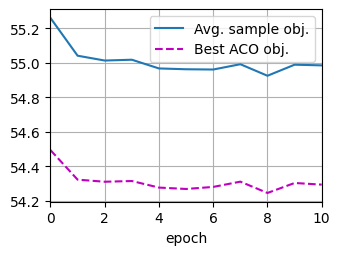

In [8]:
n_customers, n_ants = 500, 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10

train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs)

total training duration: 764.9247901439667
epoch -1: (102.14476281404495, 101.36799103021622)
epoch 0: (101.90098387002945, 101.18956172466278)
epoch 1: (101.87223601341248, 101.18196713924408)
epoch 2: (101.89538270235062, 101.17472648620605)
epoch 3: (101.91630601882935, 101.20088219642639)
epoch 4: (101.88593965768814, 101.17314261198044)
epoch 5: (101.87980383634567, 101.16843950748444)
epoch 6: (101.88135248422623, 101.16605412960052)
epoch 7: (101.89189630746841, 101.18578654527664)
epoch 8: (101.86100232601166, 101.13987922668457)
epoch 9: (101.89437836408615, 101.19978988170624)


train/avg_cost,▄▄▁▄▇▃▇▄▂▃▆▂▃▅▄▄█▂▂▇▂▂▄▃▅▃▇▁▁▃▄▂▃▃▇▄▄▄▅▄
train/best_cost,▅▄▃▃▅▄▅▄▄▆▃▆▅█▅▄▆▄▅▅▄▃█▇▁▄▄▄▄▅▃▄▄▄▅▆▆▅▆▃
train/epoch,▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇█████
train/step_in_epoch,▅▆▇█▁▆▂▃▇▄▅▂▃▃▄▄▄▄▅▆▂▃▃▃▄▁▂▃▃▄▆▇██▂▃▃▄▇▇
val/avg_best,█▃▂▂▃▂▂▂▂▁▃
val/avg_last,█▂▁▂▂▂▁▂▂▁▂
val/epoch,▁▂▂▃▄▅▅▆▇▇█
train/avg_cost,101.16432
train/best_cost,100.40111
train/epoch,9
train/step_in_epoch,64


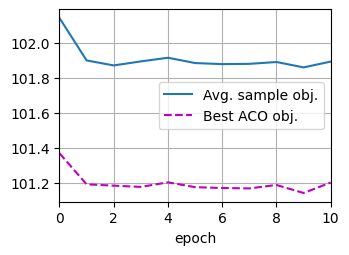

In [9]:
n_customers, n_ants = 1000, 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10

train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs)

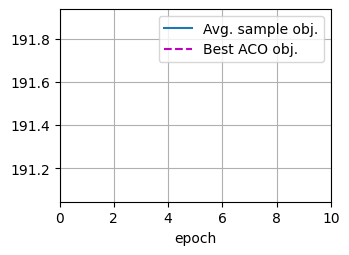

In [ ]:
n_customers, n_ants = 2000, 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10

train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs)

In [ ]:
n_customers, n_ants = 5000, 100
k_sparse = 32
steps_per_epoch = 64
epochs = 10

train(n_customers, k_sparse, n_ants, steps_per_epoch, epochs)